In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Student_performance.csv")
df.head()

,Student_ID,Student_Name,Maths,Physics,Chemistry,English,Computer_Science,Total
0,S001,Student_1,63,50,76,74,78,341
1,S002,Student_2,90,55,46,59,67,317
2,S003,Student_3,63,93,63,89,48,356
3,S004,Student_4,76,100,40,60,99,375
4,S005,Student_5,80,80,59,95,49,363


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Student_ID        300 non-null    object
 1   Student_Name      300 non-null    object
 2   Maths             300 non-null    int64 
 3   Physics           300 non-null    int64 
 4   Chemistry         300 non-null    int64 
 5   English           300 non-null    int64 
 6   Computer_Science  300 non-null    int64 
 7   Total             300 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 18.9+ KB
None
            Maths     Physics   Chemistry     English  Computer_Science  \
count  300.000000  300.000000  300.000000  300.000000        300.000000   
mean    68.216667   72.016667   68.620000   68.993333         70.913333   
std     17.740692   18.231411   17.276299   17.608715         16.993580   
min     40.000000   40.000000   40.000000   40.000000         40.000000   
25%  

In [4]:
df['Average'] = df[['Maths','Physics','Chemistry','English','Computer_Science']].mean(axis=1)

# Grade
def grade(avg):
    if avg >= 90:
        return 'A'
    elif avg >= 75:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(grade)

df.head()

,Student_ID,Student_Name,Maths,Physics,Chemistry,English,Computer_Science,Total,Average,Grade
0,S001,Student_1,63,50,76,74,78,341,68.2,C
1,S002,Student_2,90,55,46,59,67,317,63.4,C
2,S003,Student_3,63,93,63,89,48,356,71.2,C
3,S004,Student_4,76,100,40,60,99,375,75.0,B
4,S005,Student_5,80,80,59,95,49,363,72.6,C


In [5]:
marks_array = df[['Maths','Physics','Chemistry','English','Computer_Science']].values

print("Mean:", np.mean(marks_array))
print("Median:", np.median(marks_array))
print("Standard Deviation:", np.std(marks_array))

Mean: 69.752
Median: 70.0
Standard Deviation: 17.606698422286144


In [6]:
subject_means = df[['Maths','Physics','Chemistry','English','Computer_Science']].mean()
print(subject_means)

Maths               68.216667
Physics             72.016667
Chemistry           68.620000
English             68.993333
Computer_Science    70.913333
dtype: float64


In [7]:
top_students = df.sort_values(by='Total', ascending=False).head(10)
top_students[['Student_Name','Total']]

,Student_Name,Total
112,Student_113,458
204,Student_205,443
189,Student_190,443
275,Student_276,426
249,Student_250,424
140,Student_141,423
40,Student_41,422
30,Student_31,421
65,Student_66,417
148,Student_149,417


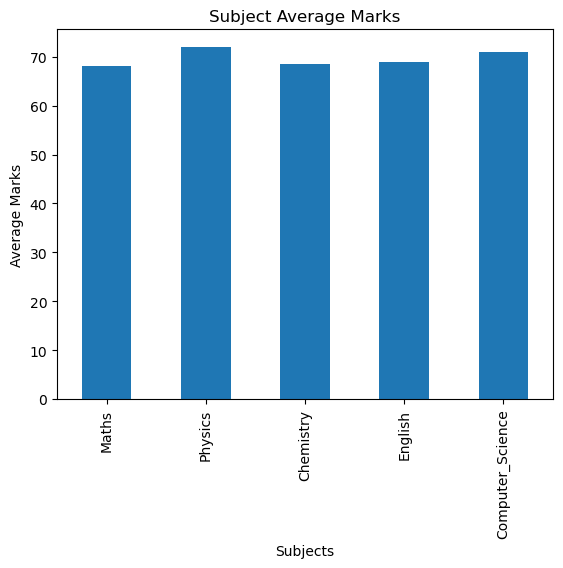

In [8]:
subject_means.plot(kind='bar')
plt.title("Subject Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

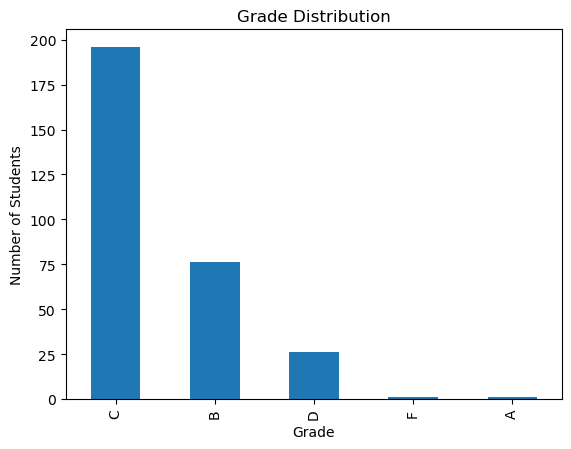

In [9]:
df['Grade'].value_counts().plot(kind='bar')
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.show()

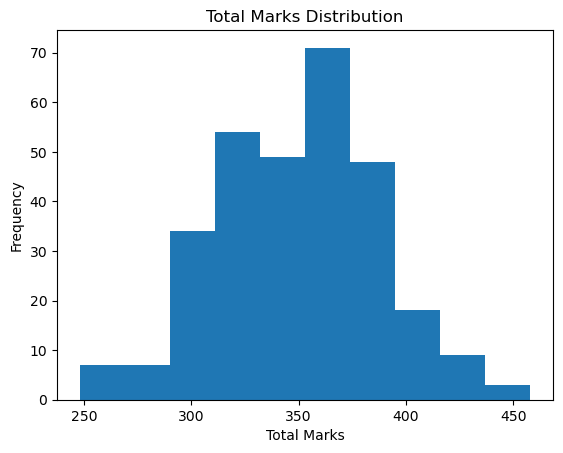

In [10]:
plt.hist(df['Total'], bins=10)
plt.title("Total Marks Distribution")
plt.xlabel("Total Marks")
plt.ylabel("Frequency")
plt.show()

In [11]:
correlation = df.corr(numeric_only=True)
print(correlation)

                     Maths   Physics  Chemistry   English  Computer_Science  \
Maths             1.000000 -0.020227  -0.084539 -0.008635         -0.071458   
Physics          -0.020227  1.000000  -0.031346  0.050038         -0.033859   
Chemistry        -0.084539 -0.031346   1.000000 -0.032396          0.058510   
English          -0.008635  0.050038  -0.032396  1.000000          0.009912   
Computer_Science -0.071458 -0.033859   0.058510  0.009912          1.000000   
Total             0.382893  0.464281   0.411425  0.473226          0.428932   
Average           0.382893  0.464281   0.411425  0.473226          0.428932   

                     Total   Average  
Maths             0.382893  0.382893  
Physics           0.464281  0.464281  
Chemistry         0.411425  0.411425  
English           0.473226  0.473226  
Computer_Science  0.428932  0.428932  
Total             1.000000  1.000000  
Average           1.000000  1.000000  


In [12]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')   # makes visuals look modern

<Figure size 640x480 with 0 Axes>

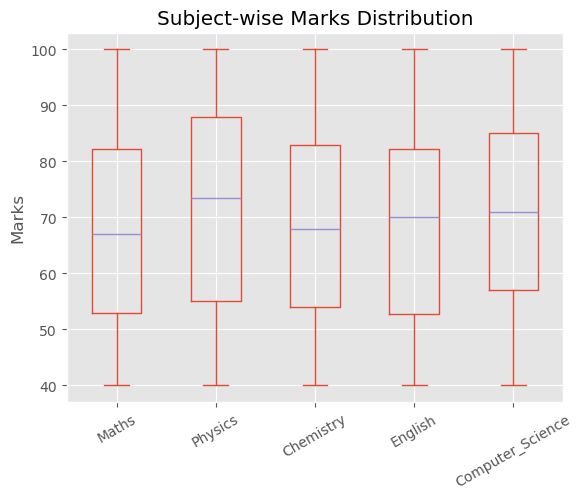

In [13]:
subjects = ['Maths','Physics','Chemistry','English','Computer_Science']

plt.figure()
df[subjects].plot(kind='box')
plt.title("Subject-wise Marks Distribution")
plt.ylabel("Marks")
plt.xticks(rotation=30)
plt.show()

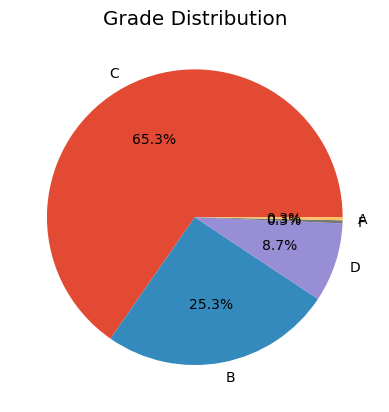

In [14]:
grade_counts = df['Grade'].value_counts()

plt.figure()
plt.pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%')
plt.title("Grade Distribution")
plt.show()

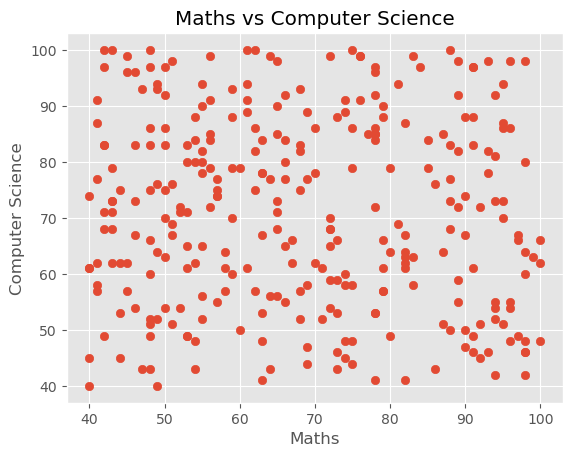

In [15]:
plt.figure()
plt.scatter(df['Maths'], df['Computer_Science'])
plt.title("Maths vs Computer Science")
plt.xlabel("Maths")
plt.ylabel("Computer Science")
plt.show()

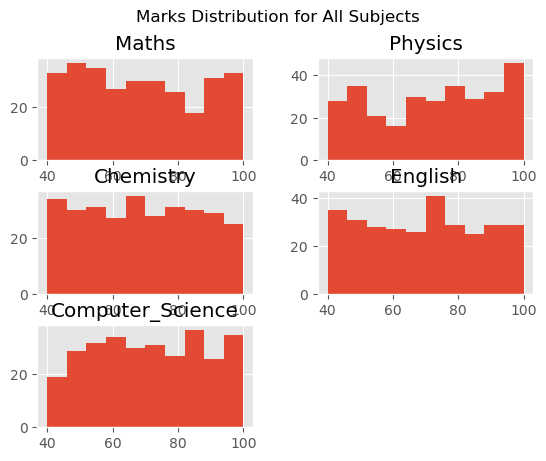

In [16]:
subjects = ['Maths','Physics','Chemistry','English','Computer_Science']

df[subjects].hist(bins=10)
plt.suptitle("Marks Distribution for All Subjects")
plt.show()

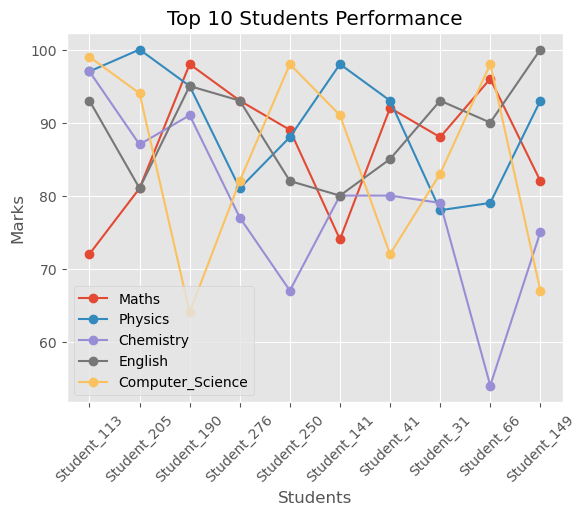

In [17]:
top10 = df.sort_values(by='Total', ascending=False).head(10)

plt.figure()
for subject in ['Maths','Physics','Chemistry','English','Computer_Science']:
    plt.plot(top10['Student_Name'], top10[subject], marker='o', label=subject)

plt.title("Top 10 Students Performance")
plt.xlabel("Students")
plt.ylabel("Marks")
plt.xticks(rotation=45)
plt.legend()
plt.show()

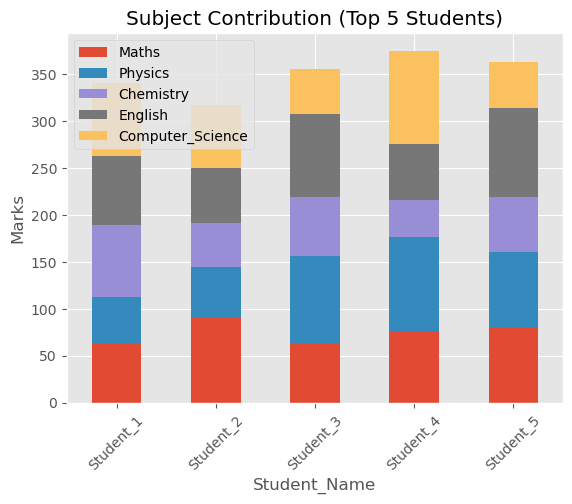

In [18]:
top5 = df.head(5)

top5.set_index('Student_Name')[['Maths','Physics','Chemistry','English','Computer_Science']].plot(kind='bar', stacked=True)

plt.title("Subject Contribution (Top 5 Students)")
plt.ylabel("Marks")
plt.xticks(rotation=45)
plt.show()

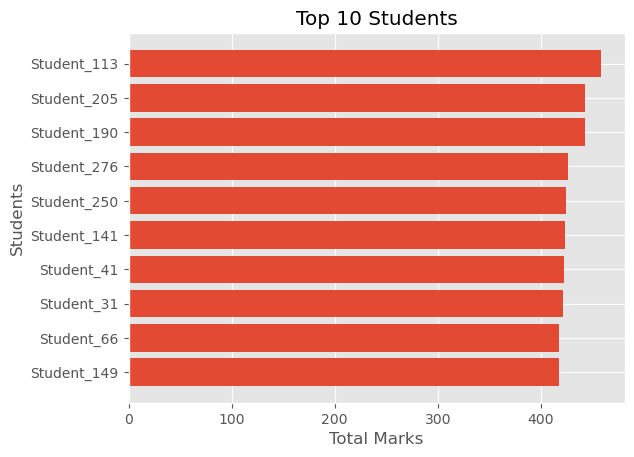

In [19]:
top10 = df.sort_values(by='Total', ascending=False).head(10)

plt.figure()
plt.barh(top10['Student_Name'], top10['Total'])
plt.title("Top 10 Students")
plt.xlabel("Total Marks")
plt.ylabel("Students")
plt.gca().invert_yaxis()
plt.show()

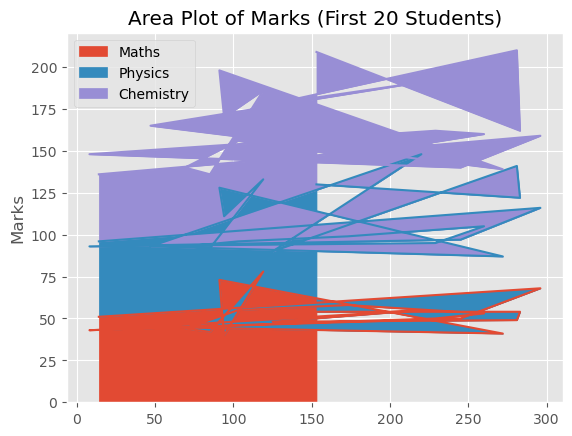

In [20]:
df_sorted = df.sort_values(by='Total')

df_sorted[['Maths','Physics','Chemistry']].head(20).plot(kind='area')

plt.title("Area Plot of Marks (First 20 Students)")
plt.ylabel("Marks")
plt.show()

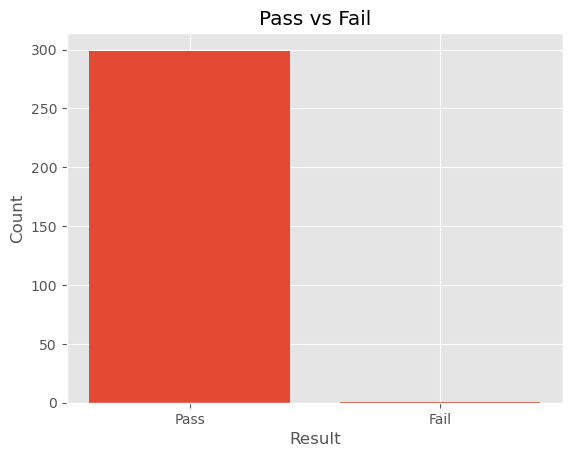

In [21]:
df['Result'] = df['Average'].apply(lambda x: 'Pass' if x >= 50 else 'Fail')

result_counts = df['Result'].value_counts()

plt.figure()
plt.bar(result_counts.index, result_counts.values)
plt.title("Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['Maths','Physics','Chemistry','English','Computer_Science']]
y = df['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.8947806286936004e-14
R2 Score: 1.0
